<a href="https://colab.research.google.com/github/kumawatmanish05/Fastag-Fraud-Detection/blob/main/FasTag_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

# **1. EDA**

In [2]:
df = pd.read_csv('/content/FastagFraudDetection.csv')
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


In [3]:
df.shape

(5000, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Transaction_ID         5000 non-null   int64 
 1   Timestamp              5000 non-null   object
 2   Vehicle_Type           5000 non-null   object
 3   FastagID               4451 non-null   object
 4   TollBoothID            5000 non-null   object
 5   Lane_Type              5000 non-null   object
 6   Vehicle_Dimensions     5000 non-null   object
 7   Transaction_Amount     5000 non-null   int64 
 8   Amount_paid            5000 non-null   int64 
 9   Geographical_Location  5000 non-null   object
 10  Vehicle_Speed          5000 non-null   int64 
 11  Vehicle_Plate_Number   5000 non-null   object
 12  Fraud_indicator        5000 non-null   object
dtypes: int64(4), object(9)
memory usage: 507.9+ KB


In [5]:
# check the null values
df.isnull().sum()


,0
Transaction_ID,0
Timestamp,0
Vehicle_Type,0
FastagID,549
TollBoothID,0
Lane_Type,0
Vehicle_Dimensions,0
Transaction_Amount,0
Amount_paid,0
Geographical_Location,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()  #for numerical features

,Transaction_ID,Transaction_Amount,Amount_paid,Vehicle_Speed
count,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,161.06200,141.261000,67.851200
std,1443.520003,112.44995,106.480996,16.597547
min,1.000000,0.00000,0.000000,10.000000
25%,1250.750000,100.00000,90.000000,54.000000
50%,2500.500000,130.00000,120.000000,67.000000
75%,3750.250000,290.00000,160.000000,82.000000
max,5000.000000,350.00000,350.000000,118.000000


In Mean for Transcation_Amount and amount_paid there is a difference of Average 20 rupees that signifies a Fraud

In [8]:
#descirbe or get the statictistcal description for numerical+categoriecal features
df.describe(include='object')

,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Geographical_Location,Vehicle_Plate_Number,Fraud_indicator
count,5000,5000,4451,5000,5000,5000,5000,5000,5000
unique,4423,7,4451,6,2,3,5,5000,2
top,1/1/2023 8:15,Bus,FTG-459-WSX-543,B-102,Regular,Large,"13.059816123454882, 77.77068662374292",KA37AB3456,Not Fraud
freq,5,716,1,1432,2858,2144,1000,1,4017


# **Observation 01**
*   Fastag ID has 549 Null Values
*   No Duplicates Entries
*   Data Types are almost correct





In [9]:
df.columns


Index(['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID',
       'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount',
       'Amount_paid', 'Geographical_Location', 'Vehicle_Speed',
       'Vehicle_Plate_Number', 'Fraud_indicator'],
      dtype='object')

In [10]:
#unique values
print("Unique Vehicle Type: ", df['Vehicle_Type'].unique())
print("Unique TollBoothID : ", df['TollBoothID'].unique())
print("Unique Lane Type : ", df['Lane_Type'].unique())
print("Unique Vehicle Dimesnions : ", df['Vehicle_Dimensions'].unique())
print("Unique Fraud Indicator : ", df['Fraud_indicator'].unique())
print("Unique GeogrphicalLocation : ", df['Geographical_Location'].unique())

Unique Vehicle Type:  ['Bus ' 'Car' 'Motorcycle' 'Truck' 'Van' 'Sedan' 'SUV']
Unique TollBoothID :  ['A-101' 'B-102' 'D-104' 'C-103' 'D-105' 'D-106']
Unique Lane Type :  ['Express' 'Regular']
Unique Vehicle Dimesnions :  ['Large' 'Small' 'Medium']
Unique Fraud Indicator :  ['Fraud' 'Not Fraud']
Unique GeogrphicalLocation :  ['13.059816123454882, 77.77068662374292'
 '13.042660878688794, 77.47580097259879'
 '12.84197701525119, 77.67547528176169'
 '12.936687032945434, 77.53113977439017'
 '13.21331620748757, 77.55413526894684']


# **2. Data Visualisation**

In [11]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns

Fraud_indicator
Not Fraud    4017
Fraud         983
Name: count, dtype: int64


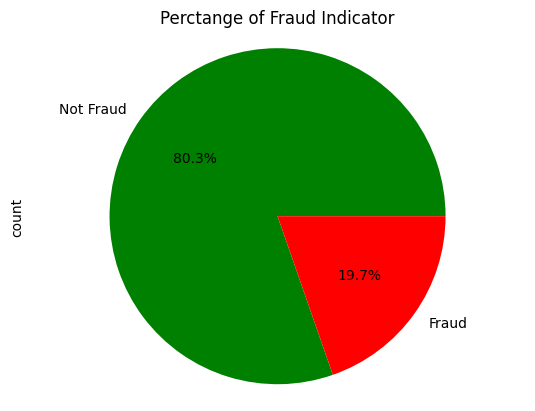

In [12]:
# percentage of fraud and not fraud
print(df['Fraud_indicator'].value_counts())
df['Fraud_indicator'].value_counts().plot(kind='pie',
                                         autopct = '%1.1f%%',
                                         colors = ['green', 'red'])
plt.title("Perctange of Fraud Indicator")
plt.axis('equal')
plt.show()


**2.1 Analyse diffent Columns**


Analysise based on Fruad indicator

In [13]:
df['Vehicle_Type'].value_counts()


,count
Vehicle_Type,
Bus,716
Car,714
Motorcycle,714
Truck,714
Van,714
Sedan,714
SUV,714


Text(0.5, 1.0, 'Vehicle Type')

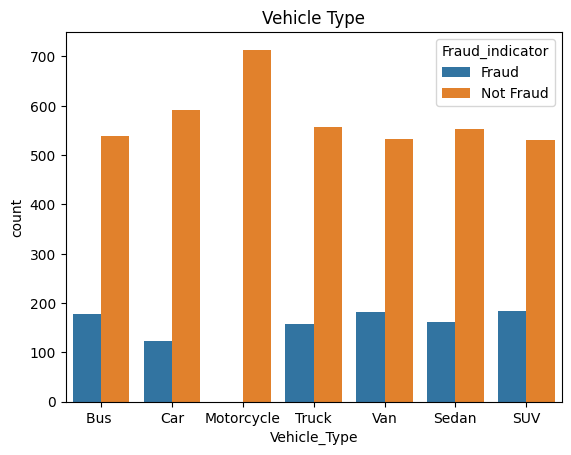

In [14]:
#Vheicle Typs
sns.countplot(x='Vehicle_Type',
              data = df,
              hue='Fraud_indicator').set_title('Vehicle Type')

Text(0.5, 1.0, 'Vehicle Dimensions')

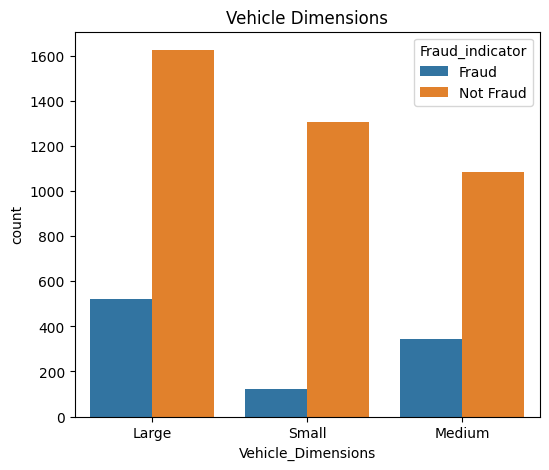

In [15]:
#Vheicle Dimensin
plt.figure(figsize=(6,5))
sns.countplot(x='Vehicle_Dimensions',
              data = df,
              hue='Fraud_indicator').set_title('Vehicle Dimensions')

Text(0.5, 1.0, 'Different Tollbooths')

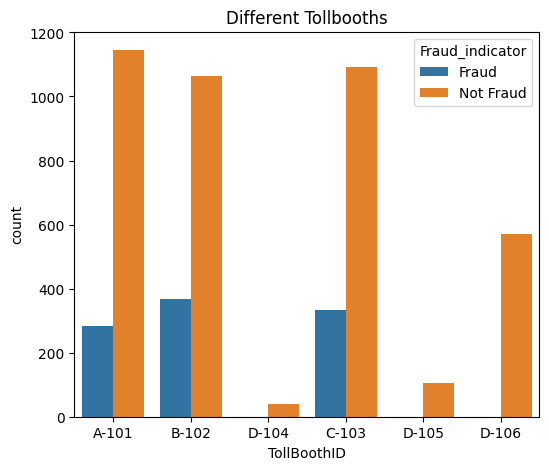

In [16]:
#Different toll booths
plt.figure(figsize=(6,5))
sns.countplot(x='TollBoothID',
              data = df,
              hue='Fraud_indicator').set_title('Different Tollbooths')

Text(0.5, 1.0, 'Different Lanes')

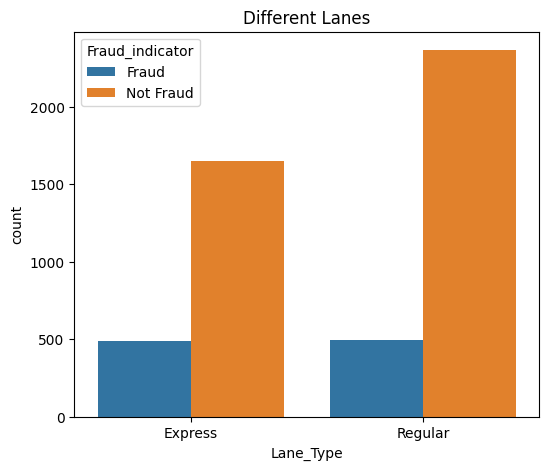

In [17]:
#Lane Type
plt.figure(figsize=(6,5))
sns.countplot(x='Lane_Type',
              data = df,
              hue='Fraud_indicator').set_title('Different Lanes')

Text(0.5, 1.0, 'Vehicle Dimensions')

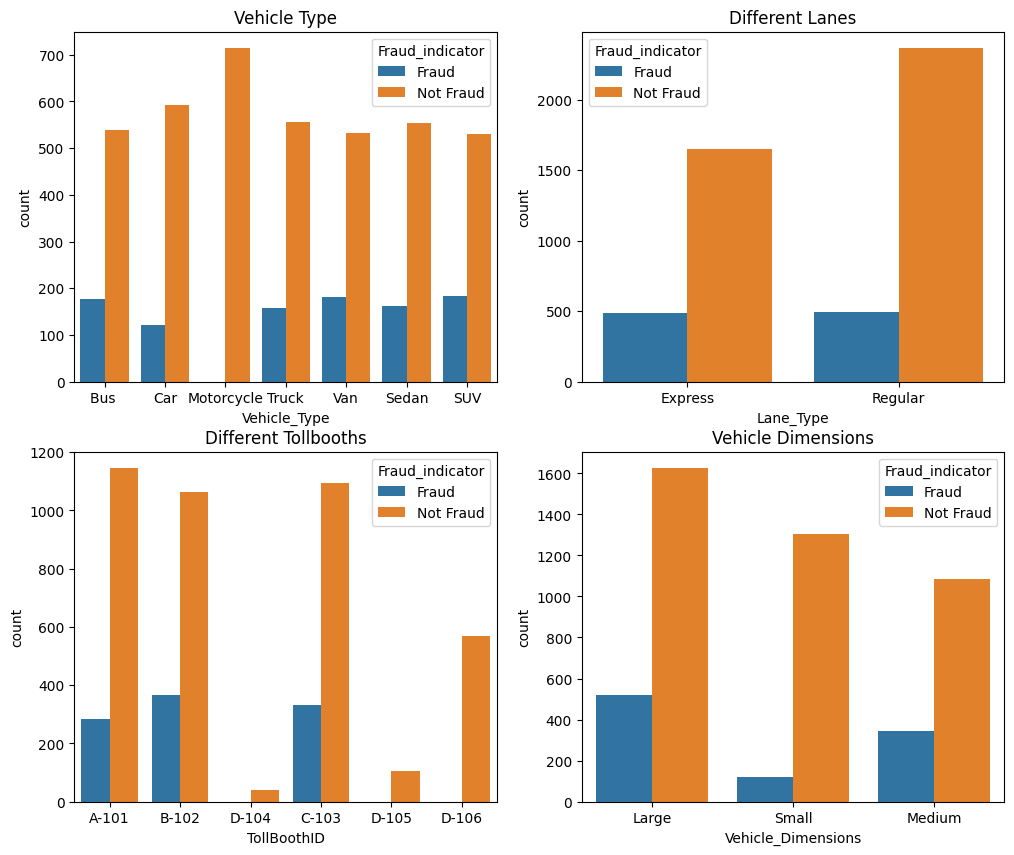

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

In [18]:
# comibing all graphs together

fig, axes = plt.subplots(2,2, figsize=(12,10))
#Vheicle Typs
sns.countplot(x='Vehicle_Type',
              data = df,
              hue='Fraud_indicator',
             ax = axes[0,0]).set_title('Vehicle Type')
#Lane Type
plt.figure(figsize=(6,5))
sns.countplot(x='Lane_Type',
              data = df,
              hue='Fraud_indicator',
             ax = axes[0,1]).set_title('Different Lanes')
#Different toll booths
plt.figure(figsize=(6,5))
sns.countplot(x='TollBoothID',
              data = df,
              hue='Fraud_indicator',
             ax = axes[1,0]).set_title('Different Tollbooths')
#Vheicle Dimensin
plt.figure(figsize=(6,5))
sns.countplot(x='Vehicle_Dimensions',
              data = df,
              hue='Fraud_indicator',
             ax = axes[1,1]).set_title('Vehicle Dimensions')

# **Observation 02**
*  Motorcycles are clan - not involved    in any fraud
*  Tollbooths 104, 105 and 106 have no fraud detected. But 101,102,103 have mix data
*  Express way has higher fraud percentage based on vehicles than regular ways
*  very less small vehicles are involved in Faud

**Distribution of transaction amount**

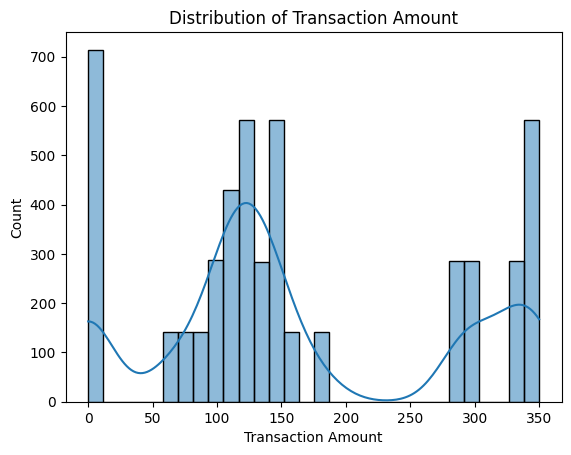

In [19]:
sns.histplot(df['Transaction_Amount'], bins=30, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel('Transaction Amount')
plt.ylabel ("Count")
plt.show()

**Distribution of paid amount**

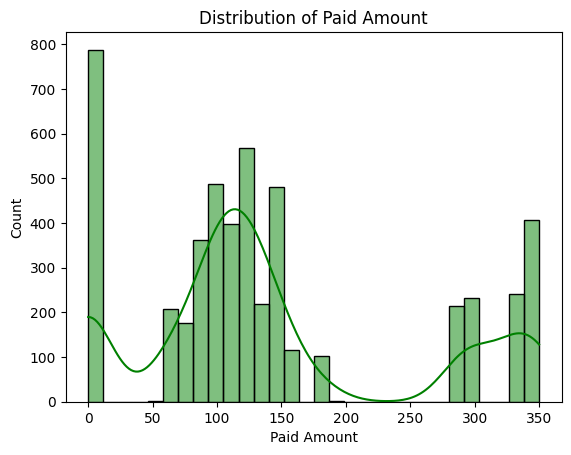

In [20]:
sns.histplot(df['Amount_paid'], bins=30, kde=True, color ='green',edgecolor= 'black')
plt.title("Distribution of Paid Amount")
plt.xlabel('Paid Amount')
plt.ylabel ("Count")
plt.show()

**Distribution of Vehicle Speed**

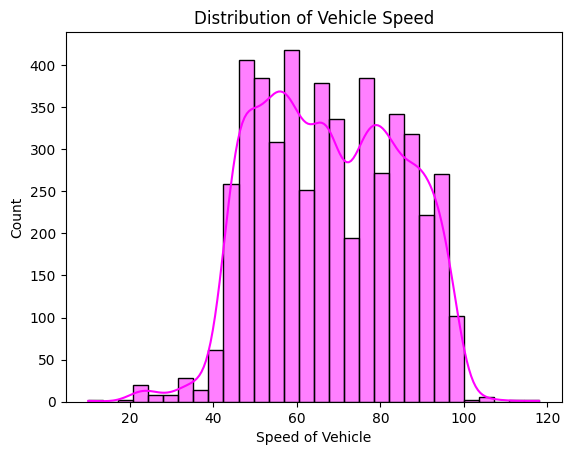

In [21]:
sns.histplot(df['Vehicle_Speed'], bins=30, kde=True, color ='magenta',edgecolor= 'black')
plt.title("Distribution of Vehicle Speed")
plt.xlabel('Speed of Vehicle')
plt.ylabel ("Count")
plt.show()

**Relationship between Tranasaction amount and Paid amount**

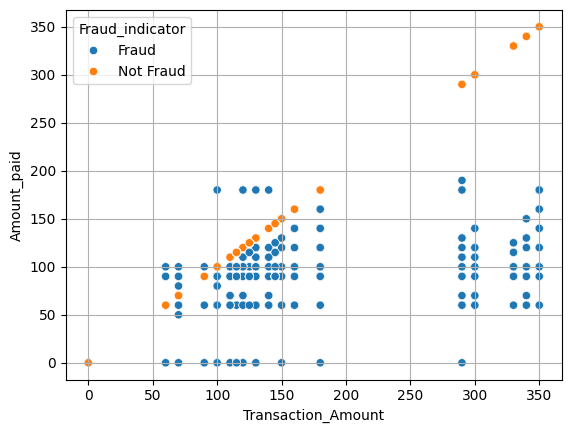

In [22]:
sns.scatterplot(x='Transaction_Amount',
                y = 'Amount_paid',
                hue='Fraud_indicator', data=df)
plt.grid()

# **Observation 03**
*  When Transaction AMount is not equal to AMount Paid ==> Fraud
*  When Transcation AMount is equal to AMount Paid ==> Not Fraud

# **3. Feature Extraction**

In [24]:
df.isnull().sum()

,0
Transaction_ID,0
Timestamp,0
Vehicle_Type,0
FastagID,549
TollBoothID,0
Lane_Type,0
Vehicle_Dimensions,0
Transaction_Amount,0
Amount_paid,0
Geographical_Location,0


In [25]:
#Extraction of State name from the number Plate
df['state_code']= df['Vehicle_Plate_Number'].str[:2]
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator,state_code
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud,KA
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud,KA
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud,KA
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud,KA
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud,KA


In [26]:
#remove vehcile number plate feature
df = df.drop('Vehicle_Plate_Number',axis=1)

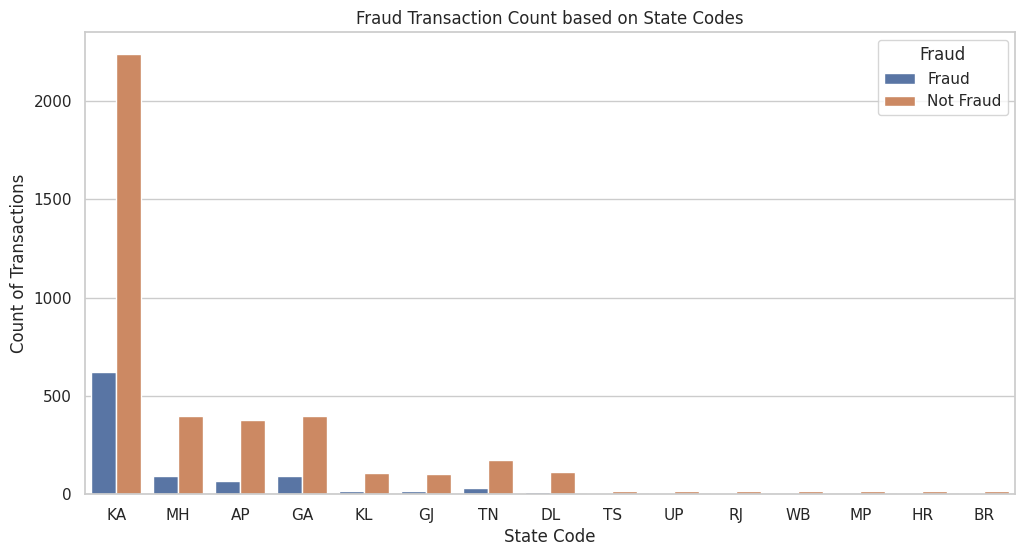

In [27]:
# visulaize fraud based on states
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,6))
sns.countplot(x='state_code',
              data = df,
              hue='Fraud_indicator')
plt.title('Fraud Transaction Count based on State Codes')
plt.xlabel('State Code')
plt.ylabel('Count of Transactions')
plt.legend(title='Fraud')
plt.show()

In [28]:
df['state_code'].value_counts()

,count
state_code,
KA,2860
GA,489
MH,488
AP,447
TN,203
DL,123
KL,121
GJ,119
TS,22


In [29]:
df.loc[df['Fraud_indicator']=='Fraud', 'state_code'].value_counts()

,count
state_code,
KA,623
GA,93
MH,92
AP,68
TN,31
GJ,16
KL,14
DL,12
TS,8


# **Observation 04**
*  Highest Fraud Count is in Karnataka(KA)

In [30]:
# analysie Timestamp to get the fraud /notfraud based on days
df['Timestamp']

,Timestamp
0,1/6/2023 11:20
1,1/7/2023 14:55
2,1/8/2023 18:25
3,1/9/2023 2:05
4,1/10/2023 6:35
...,...
4995,1/1/2023 22:18
4996,1/17/2023 13:43
4997,2/5/2023 5:08
4998,2/20/2023 20:34


In [31]:
#convert timestamp into dataframe
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [32]:
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month

In [33]:
#drop time stamp feature
df = df.drop('Timestamp', axis=1)

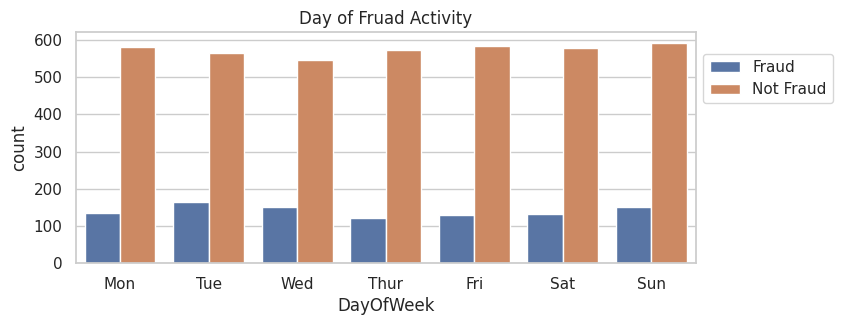

In [34]:
#visualise based on days
plt.figure(figsize=(8,3))
sns.countplot(data = df,
              x='DayOfWeek',
              hue='Fraud_indicator')
plt.title('Day of Fruad Activity')
plt.legend(loc='center left', bbox_to_anchor=(1,0.8))
plt.xticks([0,1,2,3,4,5,6], ['Mon', 'Tue', 'Wed', 'Thur','Fri','Sat','Sun'])
plt.show()

# **Correlation Matrix**

In [35]:
numericalDf = df.select_dtypes('number')

In [36]:
corr_matrix = numericalDf.corr()
corr_matrix

,Transaction_ID,Transaction_Amount,Amount_paid,Vehicle_Speed,Hour,DayOfWeek,Month
Transaction_ID,1.000000,-0.023515,0.044433,0.014378,-0.023208,0.002446,0.260075
Transaction_Amount,-0.023515,1.000000,0.870078,0.053229,-0.036980,-0.001813,-0.019824
Amount_paid,0.044433,0.870078,1.000000,0.039027,-0.026358,-0.002960,0.018105
Vehicle_Speed,0.014378,0.053229,0.039027,1.000000,-0.002259,-0.017608,0.015349
Hour,-0.023208,-0.036980,-0.026358,-0.002259,1.000000,-0.010292,0.001041
DayOfWeek,0.002446,-0.001813,-0.002960,-0.017608,-0.010292,1.000000,0.002552
Month,0.260075,-0.019824,0.018105,0.015349,0.001041,0.002552,1.000000


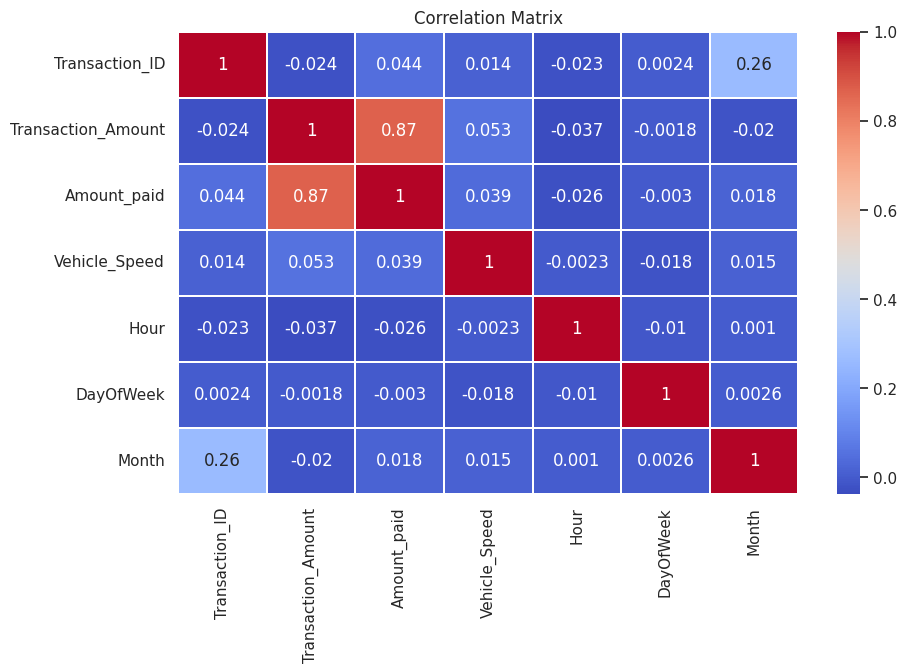

In [37]:
#plot corrrelation matrix
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,
            cmap='coolwarm', annot=True, linewidths=.2)
plt.title("Correlation Matrix")
plt.show()

In [38]:
# remove unecessary columns
# df = df.drop(['Transaction_ID','FastagID', 'Geographical_Location'], axis =1)


df.drop(['Transaction_ID','FastagID', 'Geographical_Location'], axis =1, inplace =True)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Vehicle_Type        5000 non-null   object
 1   TollBoothID         5000 non-null   object
 2   Lane_Type           5000 non-null   object
 3   Vehicle_Dimensions  5000 non-null   object
 4   Transaction_Amount  5000 non-null   int64 
 5   Amount_paid         5000 non-null   int64 
 6   Vehicle_Speed       5000 non-null   int64 
 7   Fraud_indicator     5000 non-null   object
 8   state_code          5000 non-null   object
 9   Hour                5000 non-null   int32 
 10  DayOfWeek           5000 non-null   int32 
 11  Month               5000 non-null   int32 
dtypes: int32(3), int64(3), object(6)
memory usage: 410.3+ KB


# **4. Label Encoding**

In [40]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()

In [41]:
objectColumns = ['Vehicle_Type', 'Lane_Type', 'Vehicle_Dimensions','TollBoothID','state_code', 'Fraud_indicator' ] #list of object columns
label_encoder = {}
for column in objectColumns:
    le=LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoder[column] = le

In [42]:
df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,state_code,Hour,DayOfWeek,Month
0,0,0,0,0,350,120,65,0,6,11,4,1
1,1,1,1,2,120,100,78,0,6,14,5,1
2,2,3,1,2,0,0,53,1,6,18,6,1
3,5,2,1,0,350,120,92,0,6,2,0,1
4,6,1,0,1,140,100,60,0,6,6,1,1


In [43]:
label_encoder['Fraud_indicator'].classes_

array(['Fraud', 'Not Fraud'], dtype=object)

# **5. Model Training**

In [44]:
X= df.drop(columns=['Fraud_indicator'])
y = df['Fraud_indicator']

In [45]:
# SPlit the x and y in train and testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (3500, 11)
X_test:  (1500, 11)
y_train:  (3500,)
y_test:  (1500,)
